In [1]:
from spin_lattices import KagomeLattice, SpinLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from boolean_analysis import (
    BooleanFourierAnalyzer,
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    SignalOption,
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
)
from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse

from parity import popcount
from kagome_24_fourier_full_2023_01_29 import experiment_dir, accuracy_file, overlap_file

fourier_learners_cache_dir = Path("fourier_learners_cache")
ground_state_cache_dir = Path("groundstates")


def total_hamming_weight(analyzer: BooleanFourierAnalyzer, terms: int) -> int:
    return popcount(np.asarray(analyzer.learner.get_coeffs_ser().iloc[:terms].index)).sum()


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["analyzer"]
        .truncate(keep_largest_n(row["terms"]))
        .prediction_score(scorer=scorer, max_batch_size=10000)
        for _, row in tqdm(df.iterrows())
    ]


2023-01-30 19:36:37.670 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-01-30 19:36:37.677 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
2023-01-30 19:36:37.761 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
[Debug]   [LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...
/vol/tcm10/ischurov/frustrations-eda/boolean_analysis.py:28: UserWarning: This module is deprecated and will be removed in the future.
  warnings.warn("This module is deprecated and will be removed in the future.")
/vol/tcm10/ischurov/frustrations-eda/boolean_analysis.py:29: UserWarning: Use lattice_boolean_analysis.py instead.
  warnings.warn("Use lattice_boolean_analysis.py instead.")


In [2]:
%matplotlib inline

In [3]:
lattices = {height: KagomeLattice(width=2, height=height) for height in [2, 3, 4]}


In [4]:
accuracy_terms_df = pd.read_csv(accuracy_file)
overlap_terms_df = pd.read_csv(overlap_file)

In [5]:
accuracy_terms_df

,height,J2,signal_kind,terms,accuracy,sign_overlap
0,2,0.0,sign,2,0.774892,0.807196
1,2,0.0,amplitude_median_bin,3,0.766234,0.361848
2,2,0.2,sign,2,0.774892,0.769892
3,2,0.2,amplitude_median_bin,3,0.727273,0.243326
4,2,0.4,sign,2,0.774892,0.735532
...,...,...,...,...,...,...
77,4,0.6,amplitude_median_bin,11,0.814031,0.997818
78,4,0.7,sign,131,0.703311,0.883363
79,4,0.7,amplitude_median_bin,11,0.813955,0.997887
80,4,0.8,sign,171,0.702238,0.913070


In [6]:
J2s = sorted(accuracy_terms_df.query('height==4')['J2'].unique())

In [6]:
height = 4
eigenvalues = {}
for J2 in J2s:
    system=HeisenbergJ1J2(
            lattice=lattices[height],
            J1=1,
            J2=J2,
            use_symmetries=True,
            spin_inversion=1,
            ground_state_cache_dir=ground_state_cache_dir,
            show_progress=True,
        )
    system.get_eigenstates(2)
    eigenvalues[J2] = system.eigenvalues

NameError: name 'J2s' is not defined

In [7]:
%matplotlib widget

In [8]:
sns.lineplot(
    pd.DataFrame.from_dict(eigenvalues, orient="index")
    .reset_index()
    .rename(columns={"index": "J2", 0: "E0", 1: "E1"})
    .melt(id_vars="J2", var_name="eigenstate", value_name="energy"),
    x="J2",
    y="energy",
    hue="eigenstate",
    markers=True,
    style="eigenstate",
)


NameError: name 'eigenvalues' is not defined

In [9]:
analyzers: dict[tuple[int, float, str], BooleanFourierAnalyzer] = {}
eigenstate = 1
for _, (height, J2, signal_kind, *_) in accuracy_terms_df.iterrows():
    signal_kind = {
        "sign": SignSignalKind(),
        "amplitude_median_bin": AmplitudeMedianBinSignalKind(),
        "amplitude": AmplitudeSignalKind(),
    }[signal_kind]
    analyzer = BooleanFourierAnalyzer(
        system=HeisenbergJ1J2(
            lattice=lattices[height],
            J1=1,
            J2=J2,
            use_symmetries=True,
            spin_inversion=1,
            ground_state_cache_dir=ground_state_cache_dir,
            show_progress=True,
        ),
        use_subset_symmetries=True,
        show_progress=True,
        cache_dir=fourier_learners_cache_dir,
        eigenstates=2,
    )
    train_set = analyzer.system.canonical_basis.states
    try:
        analyzer.fit(train_set, signal_opt=SignalOption(kind=signal_kind, eigenstate=eigenstate), from_cache_only=True)
        analyzers[height, J2, signal_kind.name] = analyzer
    except ValueError as e:
        print(f"Failed to load {height, J2, signal_kind.name} from cache")
        print(f"Error: {e}")
        raise


number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Making Fourier basis state info with symmetries...
MFBSIS: Building Fourier basis...
MFBSIS: Computing state info...
MFBSIS: Computing sign flip basis correspondence...
MFBSIS: Computing fourier_basis_state_info_df...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-2.pickle
Ground state energy is -23.2969224448
Restoring learner from cache: fourier_learners_cache/2afa0e8541b44a429d11c7892e1c5879-HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=1, weights=uniform_weights).lz
number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-2.pickle
Ground state ene

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Restoring learner from cache: fourier_learners_cache/c71ed4b21ba906d28ffcb87f573c6cfa-HeisenbergJ1J2-KagomeLattice2x2-1.0-0.52-True-1-SignalOption(kind=SignSignalKind, eigenstate=1, weights=uniform_weights).lz
number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.52-True-1-2.pickle
Ground state energy is -19.8135380498
Restoring learner from cache: fourier_learners_cache/a8d3308c3b319fea39ab64a3bddb025e-HeisenbergJ1J2-KagomeLattice2x2-1.0-0.52-True-1-SignalOption(kind=AmplitudeMedianBinSignalKind, eigenstate=1, weights=uniform_weights).lz
number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-2.pickle
Ground state energy is -34.6339591099
Restoring learner from cache: fourier_learners_cache/bab7141ede1467c00ef04d63e98d582d-HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=1, weights=uniform_weights).lz
number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-2.pickle
Ground state energy is -34.6339591099
Restoring learner from cache: fourier_learners_cache/163b454233c116d2b3378b6b08a86c96-HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-SignalOption(kind=AmplitudeMedianBinSignalKind, eigenstate=1, weights=uniform_weights).lz
number_spins=18
Symmetry group contains 12 elements
H

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Making Fourier basis state info with symmetries...
MFBSIS: Building Fourier basis...
MFBSIS: Computing state info...
MFBSIS: Computing sign flip basis correspondence...
MFBSIS: Computing fourier_basis_state_info_df...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-2.pickle
Ground state energy is -46.1341392314
Restoring learner from cache: fourier_learners_cache/e216d0ae25196fa0e661492ed220ce4a-HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=1, weights=uniform_weights).lz
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-2.pickle
Ground state energy is -46.1341392314
Restoring learner from cache: fourier_learners_cache/7106

In [10]:
analyzers_df = (
    pd.Series(analyzers, name="analyzer")
    .to_frame()
    .reset_index()
    .rename(columns={"level_0": "height", "level_1": "J2", "level_2": "signal_kind"})
    .merge(overlap_terms_df, on=["height", "J2", "signal_kind"], how="left")
    .assign(
        hamming_weight=lambda df: df.apply(
            lambda row: total_hamming_weight(row["analyzer"], row["terms"]), axis=1
        ),
        number_spins=lambda df: df["analyzer"].apply(lambda a: a.system.number_spins),
    )
    .assign(
        mean_hw=lambda df: df["hamming_weight"] / df["terms"],
    )
    .set_index(["height", "J2", "signal_kind"])
)


In [11]:
analyzers_df

analyzer  \
height J2  signal_kind                                                               
2      0.0 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
           amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.2 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
           amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.4 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
...                                                                            ...   
4      0.6 amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.7 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
           amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.8 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
           amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   

                                 terms  accuracy  sign_overlap  \
height J2  signal_kind                                           
2      0.0 sign                     10  0.965368      0.997419   
           amplitude_median_bin      4  0.930736      0.980970   
       0.2 sign                     10  0.965368      0.999424   
           amplitude_median_bin      4  0.909091      0.969090   
       0.4 sign                     10  0.965368      0.999986   
...                                ...       ...           ...   
4      0.6 amplitude_median_bin     11  0.814031      0.997818   
       0.7 sign                    311  0.752365      0.950128   
           amplitude_median_bin     11  0.813955      0.997887   
       0.8 sign                    351  0.746731      0.950945   
           amplitude_median_bin     11  0.809137      0.998072   

                                 hamming_weight  number_spins    mean_hw  
height J2  signal_kind                                                    
2      0.0 sign                              54            12   5.400000  
           amplitude_median_bin              14            12   3.500000  
       0.2 sign                              54            12   5.400000  
           amplitude_median_bin              14            12   3.500000  
       0.4 sign                              54            12   5.400000  
...                                         ...           ...        ...  
4      0.6 amplitude_median_bin              26            24   2.363636  
       0.7 sign                            3558            24  11.440514  
           amplitude_median_bin              28            24   2.545455  
       0.8 sign                            4054            24  11.549858  
           amplitude_median_bin              26            24   2.363636  

[82 rows x 7 columns]

In [14]:
%matplotlib inline

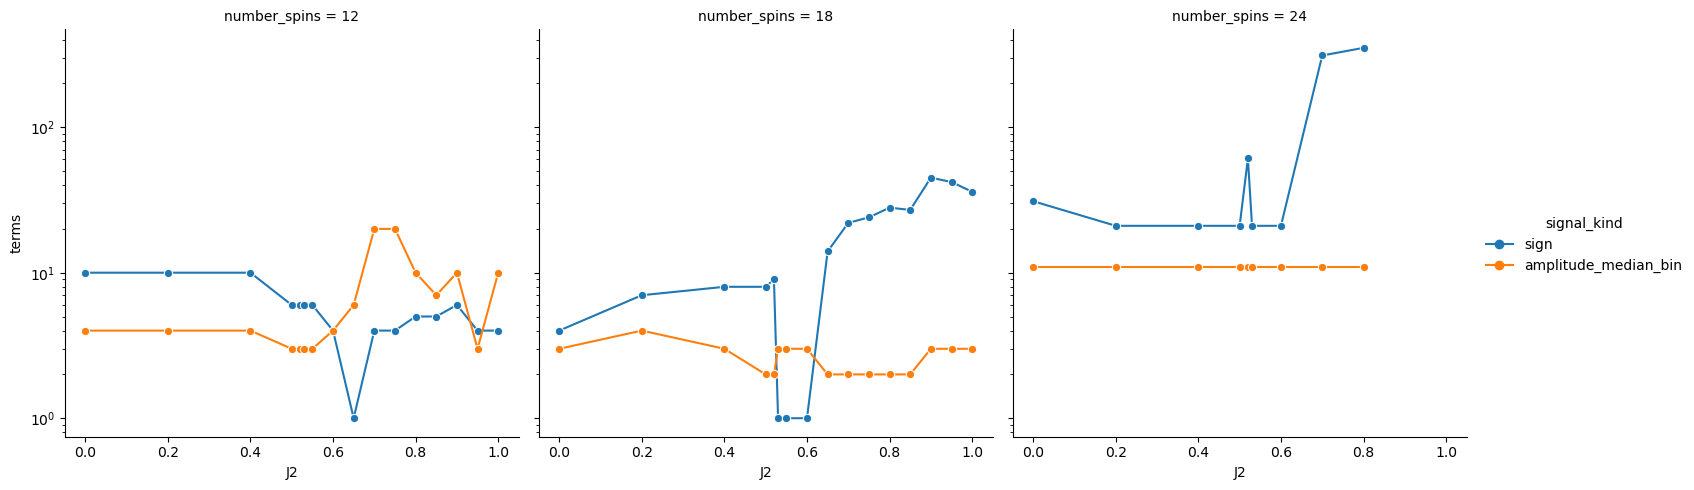

In [15]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="terms",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    # markers=True,
    style="signal_kind",
    dashes=False,
    markers=["o", "o"],
    # make y axis independent
    # facet_kws=dict(sharey=False),
).set(yscale="log")


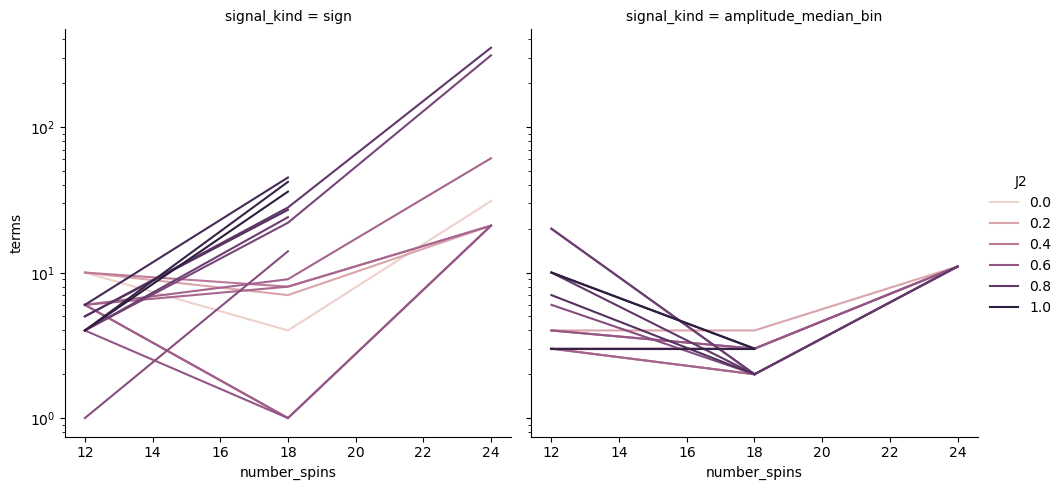

In [16]:
sns.relplot(
    analyzers_df.reset_index(),
    # .assign(J2=lambda df: df["J2"].astype(str)),
    x="number_spins",
    y="terms",
    col="signal_kind",
    hue="J2",
    kind="line",
    markers=True,
).set(yscale="log")


In [14]:
def plot_subsets(subsets, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset in zip(axes[0], subsets):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
    return fig


In [15]:
analyzers_df

analyzer  \
height J2   signal_kind                                                               
2      0.00 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
            amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.20 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
            amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.40 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
...                                                                             ...   
4      0.52 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
            amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.53 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
            amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.60 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   

                                  terms  accuracy  sign_overlap  \
height J2   signal_kind                                           
2      0.00 sign                     10  0.965368      0.997419   
            amplitude_median_bin      4  0.930736      0.980970   
       0.20 sign                     10  0.965368      0.999424   
            amplitude_median_bin      4  0.909091      0.969090   
       0.40 sign                     10  0.965368      0.999986   
...                                 ...       ...           ...   
4      0.52 sign                     61  0.754059      0.952678   
            amplitude_median_bin     11  0.815052      0.996835   
       0.53 sign                     21  0.742009      0.964055   
            amplitude_median_bin     11  0.805621      0.995115   
       0.60 sign                     21  0.724859      0.952689   

                                  hamming_weight  number_spins    mean_hw  
height J2   signal_kind                                                    
2      0.00 sign                              54            12   5.400000  
            amplitude_median_bin              14            12   3.500000  
       0.20 sign                              54            12   5.400000  
            amplitude_median_bin              14            12   3.500000  
       0.40 sign                              54            12   5.400000  
...                                          ...           ...        ...  
4      0.52 sign                             702            24  11.508197  
            amplitude_median_bin              26            24   2.363636  
       0.53 sign                             220            24  10.476190  
            amplitude_median_bin              26            24   2.363636  
       0.60 sign                             206            24   9.809524  

[77 rows x 7 columns]

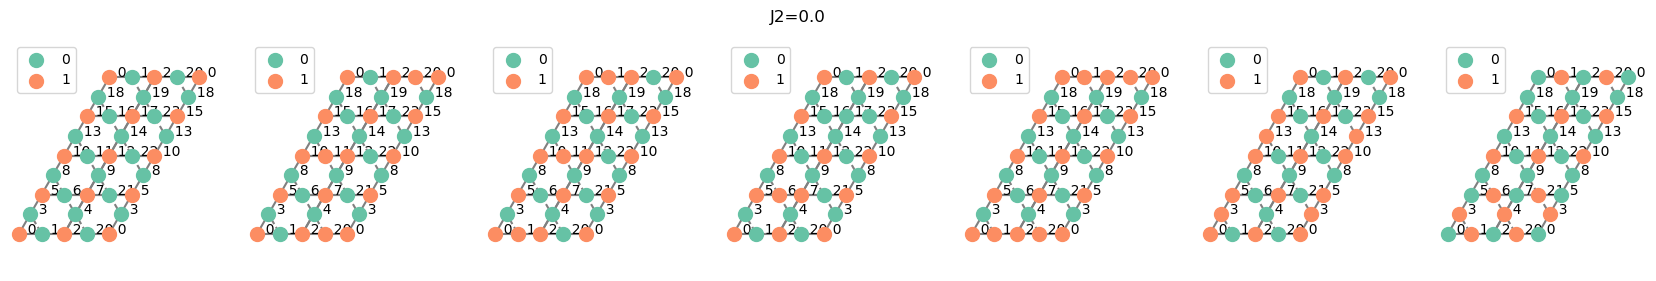

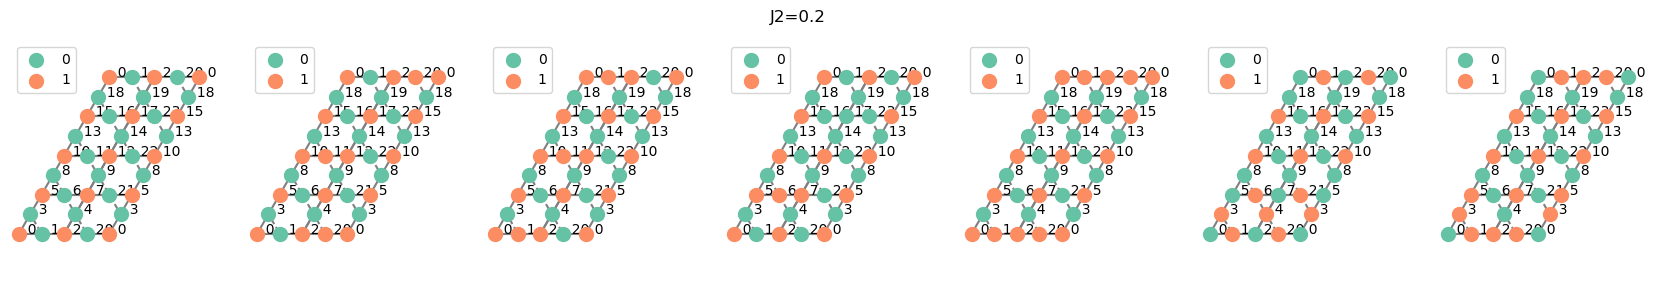

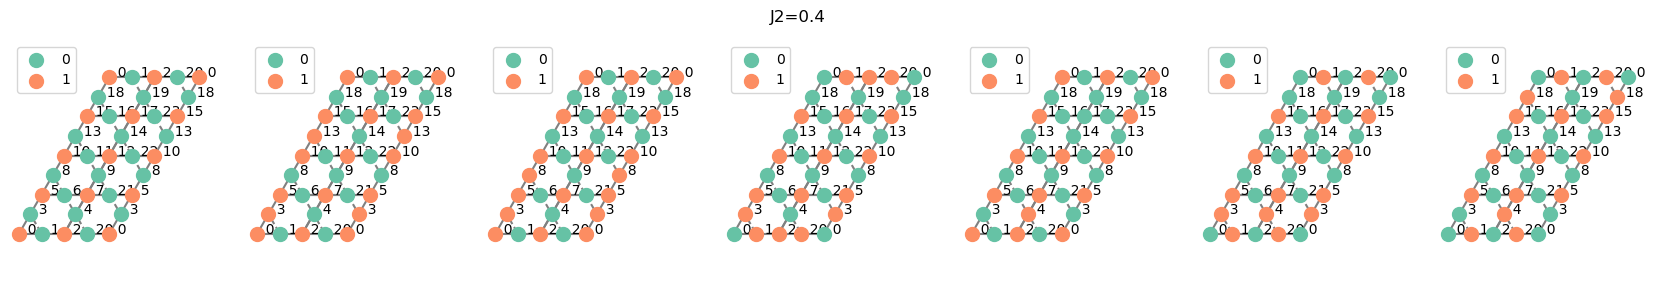

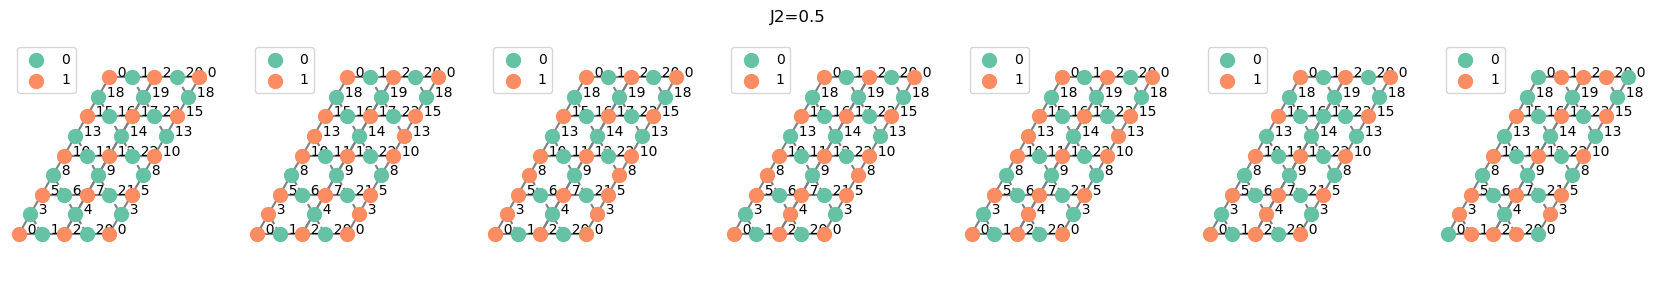

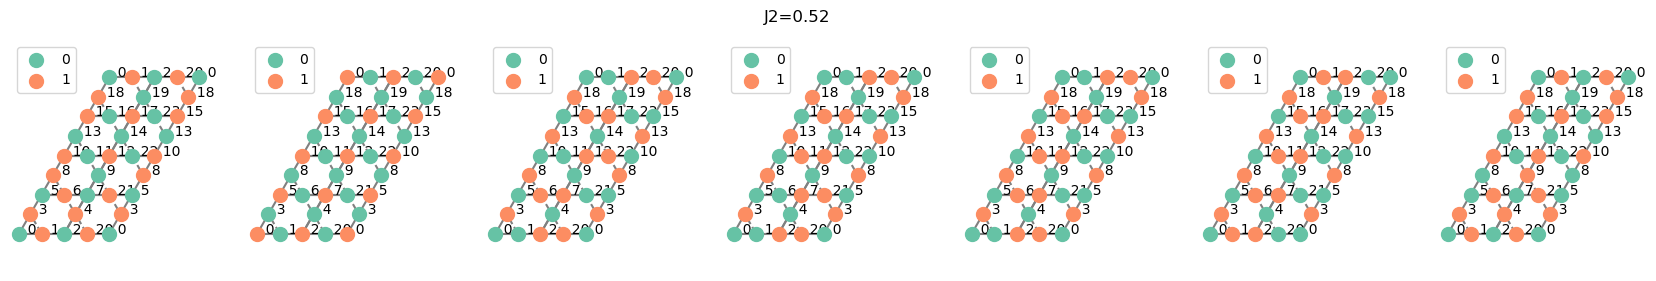

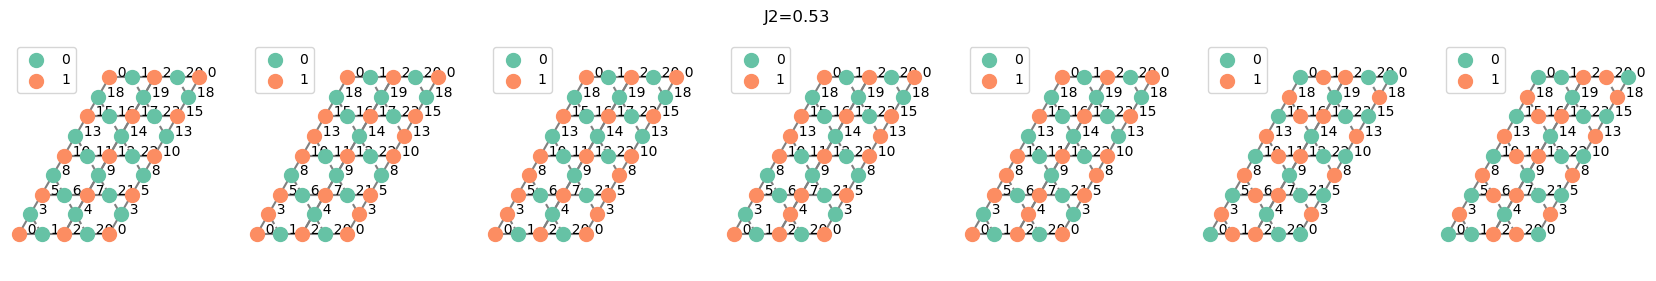

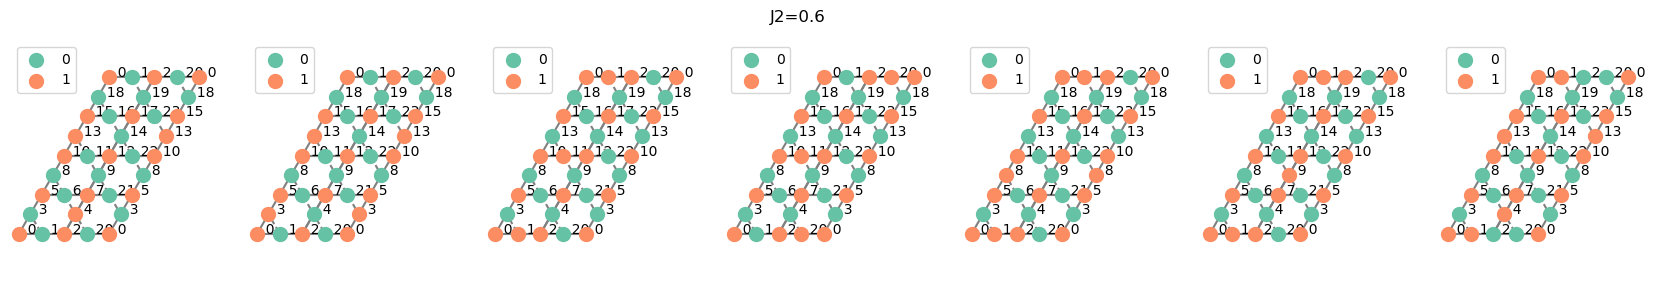

In [16]:
height = 4
# signal = "amplitude_median_bin"
max_subsets = 7
signal = "sign"
for J2, subsets in (
    analyzers_df.sort_index(level="J2")
    .xs((height, signal), level=("height", "signal_kind"))
    .assign(
        subsets=lambda df: [
            list(row["analyzer"].learner.get_coeffs_ser().iloc[: row["terms"]].index)
            for _, row in df.iterrows()
        ],
    )["subsets"]
    .items()
):
    plot_subsets(subsets[:max_subsets], KagomeLattice(width=2, height=height))
    plt.suptitle(f"J2={J2}")
    plt.show()


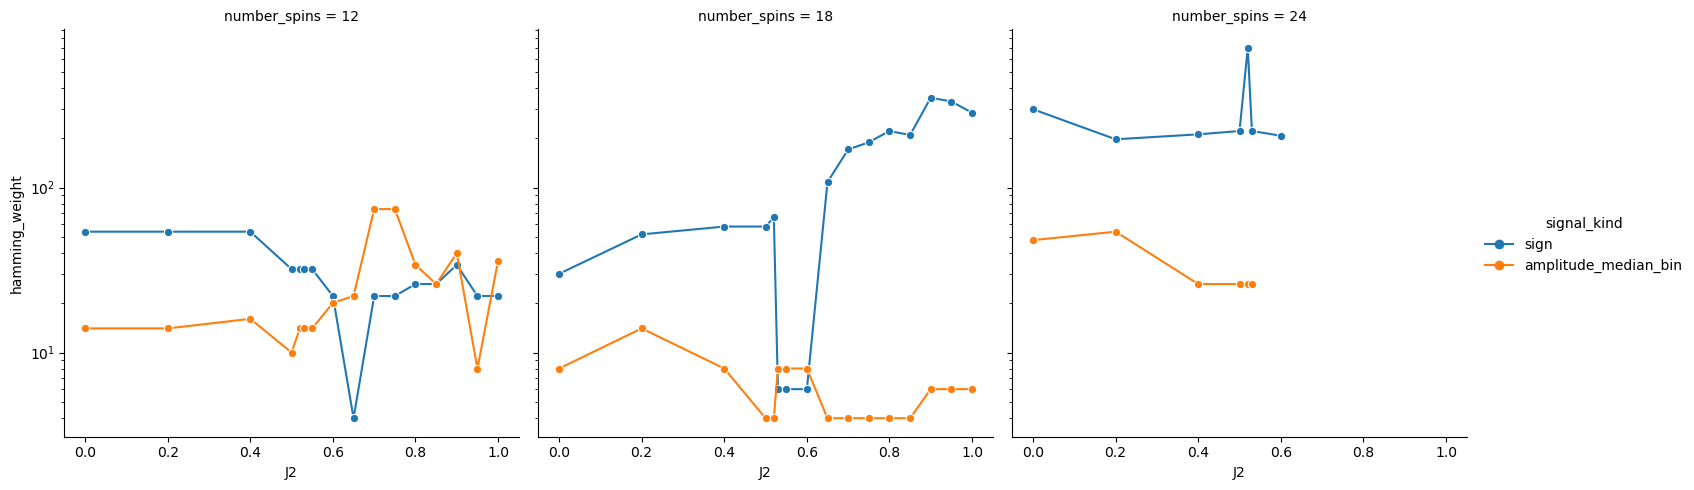

In [ ]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="hamming_weight",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    style="signal_kind",
    dashes=False,
    facet_kws=dict(sharex=True),
    markers=["o", "o"],
).set(yscale="log")


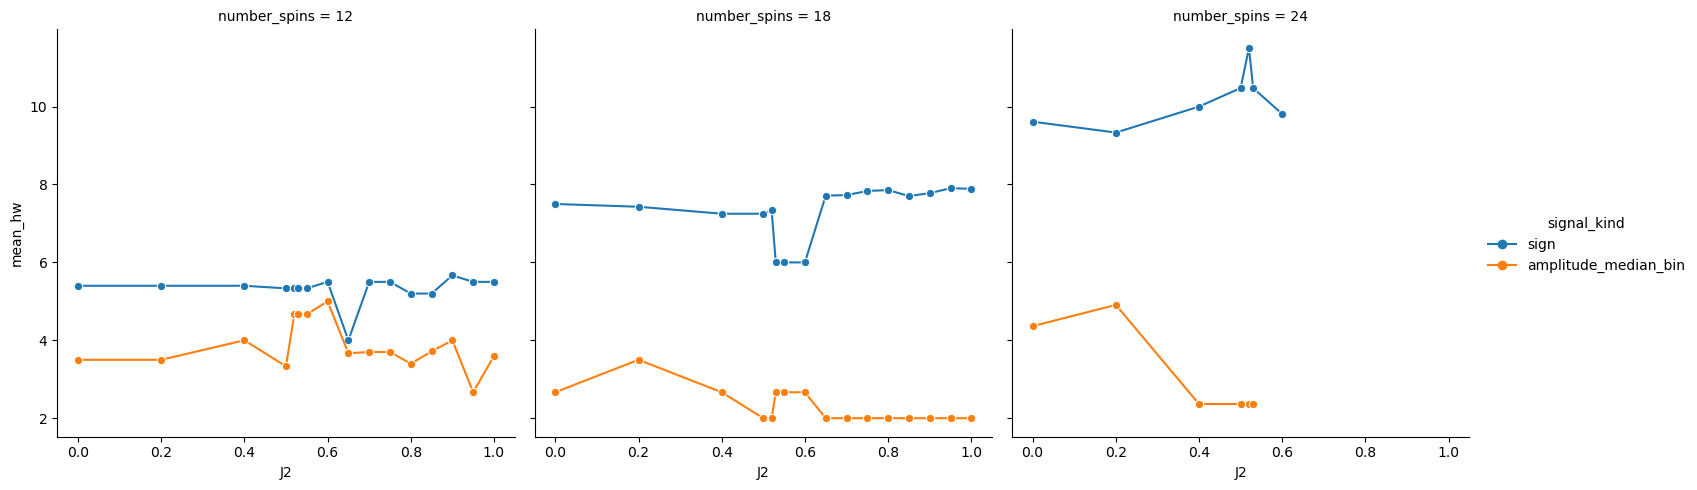

In [ ]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


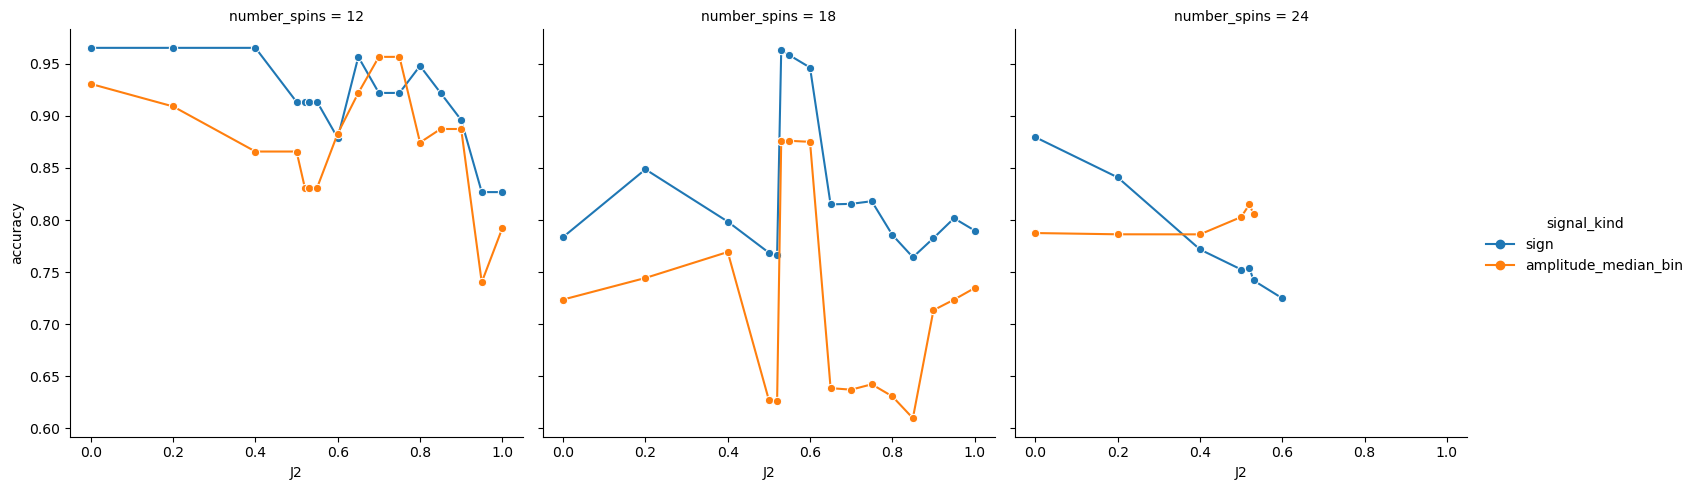

In [ ]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="accuracy",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


In [ ]:
complexity_ratio_df = (
    analyzers_df.unstack(level="signal_kind")["hamming_weight"]
    .assign(ratio=lambda df: df["sign"] / df["amplitude_median_bin"])
    .reset_index()
)


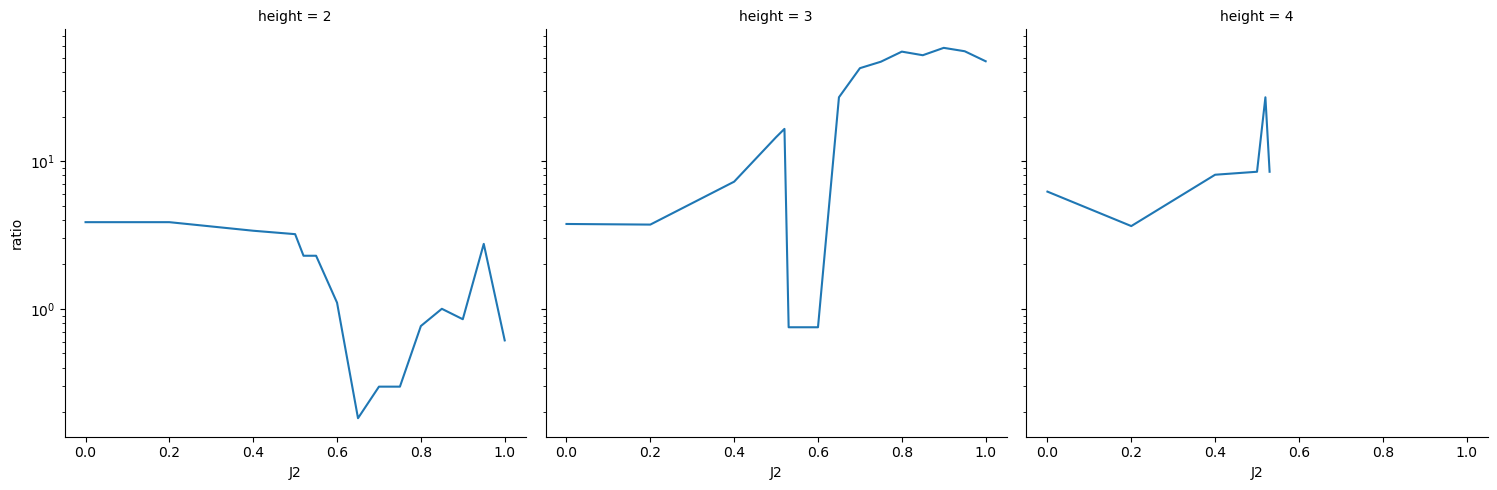

In [ ]:
sns.relplot(complexity_ratio_df, x="J2", y="ratio", col="height", kind="line").set(yscale="log")


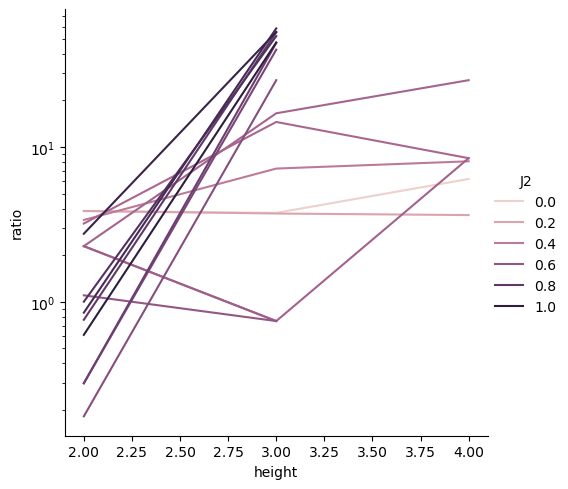

In [ ]:
sns.relplot(
    complexity_ratio_df,
    x="height",
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
